In [ ]:
# Ejecutar una vez al abrir el notebook; reiniciar el kernel si Jupyter lo solicita.
%pip install --quiet "qnexus==0.46.0" "pytket==2.18.1" pytket-offline-display numpy pandas matplotlib scipy sympy tqdm

# Modelo de Ising con Campo Transverso (TFIM)

En este notebook se implementa una simulación digital del **Modelo de Ising con Campo Transverso (TFIM)** utilizando una descomposición de **Suzuki-Trotter de primer orden**. El objetivo es construir el operador de evolución temporal como un circuito cuántico, ejecutarlo sobre el emulador H2 de Quantinuum mediante QNexus y comparar los resultados con la solución obtenida mediante diagonalización exacta (Exact Diagonalization, ED).

## Flujo del notebook

Este notebook realiza las siguientes etapas:

1. Definir el Hamiltoniano del TFIM.
2. Construir el circuito mediante trotterización.
3. Generar barridos sobre el tiempo de evolución $t$ y la razón $h/J$.
4. Ejecutar los circuitos en el emulador H2.
5. Recuperar los resultados para calcular observables y compararlos con la diagonalización exacta.

---

## Hamiltoniano

Para una cadena de $N$ espines, el Hamiltoniano del TFIM es

$$
\hat H =
-
J
\sum_{i=0}^{N-2}
\sigma_i^z\sigma_{i+1}^z
-
h
\sum_{i=0}^{N-1}
\sigma_i^x.
$$

Separando el Hamiltoniano en dos términos,

$$
\hat H=\hat H_{ZZ}+\hat H_X,
$$

donde

$$
\hat H_{ZZ}
=
-
J
\sum_{i=0}^{N-2}
\sigma_i^z\sigma_{i+1}^z,
$$

y

$$
\hat H_X
=
-
h
\sum_{i=0}^{N-1}
\sigma_i^x.
$$

Como ambos operadores no conmutan,

$$
[\hat H_{ZZ},\hat H_X]\neq0,
$$

la evolución temporal exacta

$$
U(t)=e^{-i\hat Ht}
$$

no puede separarse exactamente en el producto de ambas exponenciales.

---

## Aproximación de Suzuki-Trotter

Para aproximar la evolución temporal se utiliza la **fórmula producto de Suzuki-Trotter de primer orden** [1]:

$$
e^{-i\hat Ht}
=
e^{-i(\hat H_{ZZ}+\hat H_X)t}
\approx
\left(
e^{-i\hat H_X\Delta t}
e^{-i\hat H_{ZZ}\Delta t}
\right)^n,
$$

donde

$$
\Delta t=\frac{t}{n}
$$

es el tamaño del paso temporal y $n$ el número de pasos de Trotter. En el límite $n \rightarrow \infty$, esta aproximación converge a la evolución temporal exacta.

---

## Validación

La precisión de la aproximación de Trotter se evalúa comparando los observables obtenidos con **Diagonalización Exacta (ED)**, que calcula exactamente la evolución del sistema para cadenas pequeñas. En particular, este notebook compara la magnetización y las correlaciones del TFIM con la solución exacta para cuantificar el error introducido por la trotterización.

---

## Referencias

**[1]** M. Suzuki, *Generalized Trotter's Formula and Systematic Approximants of Exponential Operators and Inner Derivations with Applications to Many-Body Problems*, Communications in Mathematical Physics **51**, 183–190 (1976).

**[2]** S. Ebadi *et al.*, *Quantum Phases of Matter on a 256-Atom Programmable Quantum Simulator*, Nature **595**, 227–232 (2021).

---

## Estado inicial

Salvo que se indique lo contrario, todas las simulaciones comienzan desde el estado producto

$$
|\psi(0)\rangle = |00\cdots0\rangle.
$$

Este estado evoluciona bajo el Hamiltoniano del TFIM utilizando una descomposición de Suzuki-Trotter de primer orden.

## 1) Conexión y proyecto

Inicio de sesión en QNexus y configuración del proyecto activo.


In [9]:
import qnexus as qnx
qnx.login()
project = qnx.projects.get_or_create(
    name="Hackathon project",
)
qnx.context.set_active_project(project)

Already logged in. Tokens are valid.


## 2) Backends

`H2-1LE` (sin ruido) y `H2-1E` (con ruido) para dinámica; `AerState` sin shots para convergencia y tamaño finito.


In [10]:
import json
from pathlib import Path

from pytket.backends.backendresult import BackendResult


n_qbits = 8
DYNAMICS_SHOTS = 10_000
QNEXUS_RUNS_DIR = Path.cwd() / "qnexus_runs"


def prepare_run_directory(run_label, run_suffix, scan_records):
    run_root = QNEXUS_RUNS_DIR / run_label
    run_directory = run_root / run_suffix
    run_directory.mkdir(parents=True, exist_ok=False)

    (run_directory / "scan_records.json").write_text(
        json.dumps(scan_records, indent=2),
        encoding="utf-8",
    )
    (run_root / "latest_run.txt").write_text(
        str(run_directory.resolve()),
        encoding="utf-8",
    )
    return run_directory


def latest_run_directory(run_label, required=True):
    pointer = QNEXUS_RUNS_DIR / run_label / "latest_run.txt"
    if not pointer.exists():
        if required:
            raise FileNotFoundError(
                f"No existe una ejecución guardada para {run_label!r}."
            )
        return None

    run_directory = Path(pointer.read_text(encoding="utf-8").strip())
    if not run_directory.exists():
        raise FileNotFoundError(
            f"El directorio guardado no existe: {run_directory}"
        )
    return run_directory


def save_job_reference(job_reference, path):
    qnx.filesystem.save(
        ref=job_reference,
        path=Path(path),
        mkdir=True,
    )


def load_scan_records(run_directory):
    return json.loads(
        (Path(run_directory) / "scan_records.json").read_text(
            encoding="utf-8"
        )
    )


def recover_execution_records(run_directory):
    run_directory = Path(run_directory)
    execute_path = run_directory / "execute-job"
    if not execute_path.exists():
        raise FileNotFoundError(
            f"No existe una referencia de ejecución en {run_directory}."
        )

    execute_job = qnx.filesystem.load(path=execute_path)
    job_status = qnx.jobs.status(execute_job)
    status_value = getattr(
        job_status.status,
        "value",
        str(job_status.status),
    )
    if status_value != "COMPLETED":
        raise RuntimeError(
            f"El job no está completo: {status_value}. "
            "Revisa su estado antes de recuperar resultados."
        )

    result_refs = qnx.jobs.results(execute_job)
    scan_records = load_scan_records(run_directory)
    if len(result_refs) != len(scan_records):
        raise RuntimeError(
            f"Se encontraron {len(result_refs)} resultados para "
            f"{len(scan_records)} registros."
        )

    cache_directory = run_directory / "result_cache"
    cache_directory.mkdir(exist_ok=True)
    backend_results = []

    for index, result_ref in enumerate(
        tqdm(
            result_refs,
            desc="Recuperando resultados",
            unit="resultado",
        )
    ):
        cache_path = cache_directory / f"{index:04d}.json"
        if cache_path.exists():
            backend_result = BackendResult.from_dict(
                json.loads(cache_path.read_text(encoding="utf-8"))
            )
        else:
            backend_result = result_ref.download_result()
            temporary_path = cache_path.with_suffix(".tmp")
            temporary_path.write_text(
                json.dumps(backend_result.to_dict()),
                encoding="utf-8",
            )
            temporary_path.replace(cache_path)
        backend_results.append(backend_result)

    return [
        {**record, "backend_result": backend_result}
        for record, backend_result in zip(
            scan_records,
            backend_results,
            strict=True,
        )
    ]


## 3) Construcción del circuito trotterizado

Funciones para la evolución X, interacción ZZ y ensamblado de pasos de Trotter.


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from pytket.circuit import Circuit
from pytket.extensions.offline_display import render_circuit_jupyter
from tqdm.auto import tqdm


def add_x_evolution(
    c: Circuit,
    q: int,
    h: float,
    dt: float,
) -> None:
    angle_x = (-2.0 * h * dt) / np.pi
    c.Rx(angle_x, q)


def add_zz_evolution(
    c: Circuit,
    q0: int,
    q1: int,
    J: float,
    dt: float,
) -> None:
    angle_zz = (-2.0 * J * dt) / np.pi
    c.CX(q0, q1)
    c.Rz(angle_zz, q1)
    c.CX(q0, q1)


def build_trotter_step(
    c: Circuit,
    h: float,
    J: float,
    dt: float,
    n: int,
) -> None:
    for q in range(n):
        add_x_evolution(c, q, h, dt)

    for q in range(n - 1):
        add_zz_evolution(c, q, q + 1, J, dt)


def build_trotter_circuit(
    h: float,
    J: float,
    t: float,
    steps: int,
    n_qbits: int,
) -> Circuit:
    dt = float(t) / int(steps)
    circuit = Circuit(int(n_qbits))

    for _ in range(int(steps)):
        build_trotter_step(circuit, h, J, dt, int(n_qbits))

    return circuit


## 4) Ejemplo mínimo

Circuito de 2 qubits para inspeccionar visualmente la estructura trotterizada.


In [89]:
circuit = build_trotter_circuit(
    h=1.0,
    J=1.0,
    t=1.0,
    steps=10,
    n_qbits=2
    )

render_circuit_jupyter(circuit)

## 5) Generación del barrido TFIM

Función que genera los circuitos para cada combinación de \(h/J\) y tiempo, con metadatos de trazabilidad.


In [8]:
import datetime

def generate_tfim_trotter_scan(
    hj_ratios,
    times,
    J=1.0,
    steps=100,
    n=8,
    measure=True,
    name_prefix="tfim",
):
    """
    Genera todos los circuitos del barrido TFIM.

    El orden de salida es ratio -> tiempo. Ese orden es el que usan
    las celdas de simulacion local y las graficas posteriores.
    """
    jobname_suffix = datetime.datetime.now().strftime("%Y_%m_%d-%H_%M_%S")
    ratios = np.asarray(hj_ratios, dtype=float)
    times = np.asarray(times, dtype=float)

    circuits = []
    scan_records = []

    for ratio_index, ratio in enumerate(ratios):
        for time_index, t in enumerate(times):
            circuit_index = len(circuits)
            circuit_name = f"{name_prefix}-{jobname_suffix}-{circuit_index}"

            circuit = build_trotter_circuit(
                h=ratio * J,
                J=J,
                t=t,
                steps=steps,
                n_qbits=n,
            )
            if measure:
                circuit.measure_all()

            circuits.append(circuit)
            scan_records.append(
                {
                    "index": circuit_index,
                    "ratio_index": ratio_index,
                    "time_index": time_index,
                    "ratio": float(ratio),
                    "time": float(t),
                    "J": float(J),
                    "steps": int(steps),
                    "dt": float(t / steps),
                    "n": int(n),
                    "name": circuit_name,
                }
            )

    return circuits, scan_records, jobname_suffix

## 6) Dinámica parametrizada por backend

Generación, compilación, ejecución, recuperación y análisis usando el backend recibido por `run_tfim_dynamics`.


In [200]:
HJ_RATIOS = np.array([0.5, 0.9, 1.0, 1.1, 2.0])
DYNAMICS_TIMES = np.linspace(0, 1, 25)[1:]
DYNAMICS_J = 1.0
DYNAMICS_STEPS = 25


def run_tfim_dynamics(
    backend,
    backend_name: str,
    run_label: str,
    *,
    force_new: bool = False,
):
    """Ejecuta el barrido completo y grafica ED frente al backend."""
    run_directory = (
        None
        if force_new
        else latest_run_directory(run_label, required=False)
    )
    execute_path = (
        None if run_directory is None else run_directory / "execute-job"
    )

    if execute_path is None or not execute_path.exists():
        compile_path = (
            None if run_directory is None else run_directory / "compile-job"
        )
        if compile_path is None or not compile_path.exists():
            circuits, scan_records, suffix = generate_tfim_trotter_scan(
                hj_ratios=HJ_RATIOS,
                times=DYNAMICS_TIMES,
                J=DYNAMICS_J,
                steps=DYNAMICS_STEPS,
                n=n_qbits,
                measure=True,
                name_prefix=f"tfim-{run_label}",
            )
            run_directory = prepare_run_directory(
                run_label, suffix, scan_records
            )
            compile_path = run_directory / "compile-job"
            circuit_refs = [
                qnx.circuits.upload(circuit=circuit, name=record["name"])
                for circuit, record in tqdm(
                    zip(circuits, scan_records, strict=True),
                    total=len(circuits),
                    desc=f"Subiendo circuitos {backend_name}",
                    unit="circuito",
                )
            ]
            compile_job = qnx.start_compile_job(
                programs=circuit_refs,
                backend_config=backend,
                optimisation_level=2,
                name=f"{run_label}-compile-{run_directory.name}",
                project=project,
            )
            save_job_reference(compile_job, compile_path)
        else:
            compile_job = qnx.filesystem.load(path=compile_path)

        qnx.jobs.wait_for(compile_job)
        compiled_circuits = [
            item.get_output() for item in qnx.jobs.results(compile_job)
        ]
        execute_job = qnx.start_execute_job(
            programs=compiled_circuits,
            backend_config=backend,
            n_shots=[DYNAMICS_SHOTS] * len(compiled_circuits),
            name=f"{run_label}-execute-{run_directory.name}",
            project=project,
        )
        execute_path = run_directory / "execute-job"
        save_job_reference(execute_job, execute_path)
        qnx.jobs.wait_for(execute_job)
    else:
        execute_job = qnx.filesystem.load(path=execute_path)
        qnx.jobs.wait_for(execute_job)
        print(f"Reutilizando ejecución {backend_name}: {run_directory}")

    execution_records = recover_execution_records(run_directory)
    dynamics_df = build_dynamics_dataframe(
        execution_records=execution_records,
        hj_ratios=HJ_RATIOS,
        times=DYNAMICS_TIMES,
        J=DYNAMICS_J,
        n=n_qbits,
    )
    csv_path = run_directory / "dynamics_observables.csv"
    dynamics_df.to_csv(csv_path, index=False)

    graph_ed_and_backend(
        dynamics_df, n=n_qbits, backend_name=backend_name
    )
    plt.show()
    graph_backend_errors(
        dynamics_df, n=n_qbits, backend_name=backend_name
    )
    plt.show()
    print(f"Resultados guardados en: {csv_path}")
    return dynamics_df


## 7) Observables del backend

Medias y errores estándar obtenidos de los counts.


In [201]:
from matplotlib.lines import Line2D


OBSERVABLE_KEYS = ("mz", "mz2", "czz")
CONFIDENCE_Z = 1.96


def _z_observable_values(bitstring, n: int) -> np.ndarray:
    bits = np.asarray(tuple(bitstring), dtype=int)

    z_values = 1 - 2 * bits # Z|0> = |0>, Z|1> = -|1> tal que, z_values = 1 para |0> y z_values = -1 para |1>
    mz = np.mean(z_values)
    mz2 = mz**2
    czz = np.mean([z_values[q] * z_values[q + 1] for q in range(n - 1)]) # Correlación ZZ entre qubits adyacentes
    return np.array([mz, mz2, czz], dtype=float)


def z_observables_from_probability_result(
    backend_result,
    n: int,
) -> tuple[float, float, float]:
    """Observables exactos desde un resultado de estado de AerState."""
    probabilities = (
        backend_result
        .get_probability_distribution()
        .as_dict()
    )

    means = np.zeros(3, dtype=float)
    for bitstring, probability in probabilities.items():
        means += float(probability) * _z_observable_values(bitstring, n) # probabilidad ponderada de los observables Z 

    return tuple(float(value) for value in means)


def z_observables_from_empirical_result(
    backend_result,
    n: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Medias y errores estándar desde counts del backend."""
    counts = (
        backend_result
        .get_empirical_distribution()
        .as_counter()
    )
    total_shots = int(sum(counts.values()))
    if total_shots < 1:
        raise ValueError("El resultado empírico no contiene shots.")

    weighted_sum = np.zeros(3, dtype=float)
    weighted_square_sum = np.zeros(3, dtype=float)

    for bitstring, count in counts.items():
        values = _z_observable_values(bitstring, n)
        weighted_sum += int(count) * values
        weighted_square_sum += int(count) * values**2

    means = weighted_sum / total_shots

    sample_variances = (
        weighted_square_sum - total_shots * means**2
    ) / (total_shots - 1) 

    standard_errors = np.sqrt(
        np.maximum(sample_variances, 0.0) / total_shots
    )

    return means, standard_errors


def empirical_observables_grid(
    execution_records,
    hj_ratios,
    times,
    n: int,
):
    ratios = np.asarray(hj_ratios, dtype=float)
    times = np.asarray(times, dtype=float)
    shape = (len(ratios), len(times))

    means = {
        key: np.full(shape, np.nan, dtype=float)
        for key in OBSERVABLE_KEYS
    }
    standard_errors = {
        key: np.full(shape, np.nan, dtype=float)
        for key in OBSERVABLE_KEYS
    }

    for record in execution_records:
        ratio_matches = np.flatnonzero(
            np.isclose(ratios, record["ratio"])
        )
        time_matches = np.flatnonzero(
            np.isclose(times, record["time"])
        )
        if len(ratio_matches) != 1 or len(time_matches) != 1:
            raise ValueError(
                "No se pudo asociar de forma única el resultado con el barrido."
            )

        values, errors = z_observables_from_empirical_result(
            record["backend_result"],
            n,
        )
        i = int(ratio_matches[0])
        j = int(time_matches[0])

        for observable_index, key in enumerate(OBSERVABLE_KEYS):
            means[key][i, j] = values[observable_index]
            standard_errors[key][i, j] = errors[observable_index]

    return ratios, times, means, standard_errors


def graph_backend_observables_in_time(
    dynamics_df,
    n: int,
    backend_name: str,
):
    ratios = np.sort(dynamics_df["h_over_J"].unique())

    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(ratios)))
    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 10),
        sharex=True,
        constrained_layout=True,
    )
    plot_specs = [
        ("mz", axes[0], r"$\langle M_z(t) \rangle$", r"$M_z$"),
        ("czz", axes[1], r"$\langle Z_i Z_{i+1}(t) \rangle$", r"$C_{ZZ}$"),
        ("mz2", axes[2], r"$\langle M_z^2(t) \rangle$", r"$M_z^2$"),
    ]

    for key, axis, ylabel, title in plot_specs:
        observable_data = dynamics_df[
            dynamics_df["observable"] == key
        ]
        for color, ratio in zip(colors, ratios):
            ratio_data = observable_data[
                np.isclose(observable_data["h_over_J"], ratio)
            ].sort_values("time")
            axis.plot(
                ratio_data["time"],
                ratio_data["ed_value"],
                color=color,
                linewidth=2,
            )
            axis.errorbar(
                ratio_data["time"],
                ratio_data["backend_value"],
                yerr=CONFIDENCE_Z * ratio_data["standard_error"],
                color=color,
                fmt="o",
                markersize=4,
                markerfacecolor="white",
                markeredgewidth=1,
                capsize=4,
                capthick=1.25,
                elinewidth=1.25,
                alpha=1.0,
                zorder=3,
            )

        axis.set_ylabel(ylabel)
        axis.set_title(title)
        axis.axhline(0, color="black", linewidth=0.8, alpha=0.4)
        axis.grid(alpha=0.25)

    axes[-1].set_xlabel(r"Tiempo $t$")

    ratio_handles = [
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=2,
            label=fr"$h/J={ratio:.3g}$",
        )
        for color, ratio in zip(colors, ratios)
    ]
    method_handles = [
        Line2D(
            [0],
            [0],
            color="black",
            linewidth=2,
            label="ED",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            marker="o",
            linestyle="none",
            markersize=4,
            markerfacecolor="white",
            label=f"{backend_name} (IC 95 %)",
        ),
    ]
    fig.legend(
        handles=ratio_handles + method_handles,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
    )
    fig.suptitle(
        f"Dinámica TFIM: ED vs {backend_name}, N={n}, "
        f"{DYNAMICS_SHOTS:,} shots"
    )

    return fig, axes


## 8) Diagonalización exacta y gráficas comparativas


In [202]:
from functools import lru_cache

import pandas as pd
from scipy.linalg import eigh


OBSERVABLE_KEYS = ("mz", "mz2", "czz")


@lru_cache(maxsize=None)
def exact_tfim_model(h: float, J: float, n: int):
    """Diagonaliza el TFIM abierto y construye observables diagonales en Z."""
    h = float(h)
    J = float(J)
    n = int(n)
    if n < 2:
        raise ValueError("CZZ requiere al menos dos qubits.")

    dimension = 2**n
    basis = np.arange(dimension, dtype=np.uint64)
    positions = np.arange(n, dtype=np.uint64)
    bits = ((basis[:, None] >> positions) & 1).astype(int)
    z_values = 1 - 2 * bits

    mz_values = np.mean(z_values, axis=1)
    mz2_values = mz_values**2
    czz_values = np.mean(
        z_values[:, :-1] * z_values[:, 1:],
        axis=1,
    )
    zz_sum = np.sum(
        z_values[:, :-1] * z_values[:, 1:],
        axis=1,
    )

    hamiltonian = np.diag(-J * zz_sum).astype(complex)
    rows = np.arange(dimension)
    for site in range(n):
        flipped = basis ^ np.uint64(1 << site)
        hamiltonian[rows, flipped.astype(int)] -= h

    eigenvalues, eigenvectors = eigh(hamiltonian)
    initial_state = np.zeros(dimension, dtype=complex)
    initial_state[0] = 1.0
    initial_coefficients = eigenvectors.conj().T @ initial_state

    observable_values = {
        "mz": mz_values,
        "mz2": mz2_values,
        "czz": czz_values,
    }
    return (
        eigenvalues,
        eigenvectors,
        initial_coefficients,
        observable_values,
    )


@lru_cache(maxsize=None)
def exact_reference_observables(
    h: float,
    J: float,
    t: float,
    n: int,
):
    (
        eigenvalues,
        eigenvectors,
        initial_coefficients,
        observable_values,
    ) = exact_tfim_model(float(h), float(J), int(n))

    phases = np.exp(-1j * eigenvalues * float(t))
    state = eigenvectors @ (phases * initial_coefficients)
    probabilities = np.abs(state) ** 2

    return {
        key: float(probabilities @ observable_values[key])
        for key in OBSERVABLE_KEYS
    }


def build_dynamics_dataframe(
    execution_records,
    hj_ratios,
    times,
    J: float,
    n: int,
):
    ratios, times, backend_values, standard_errors = (
        empirical_observables_grid(
            execution_records,
            hj_ratios,
            times,
            n,
        )
    )

    rows = []
    for ratio_index, ratio in enumerate(ratios):
        for time_index, time in enumerate(times):
            ed_values = exact_reference_observables(
                h=float(ratio * J),
                J=float(J),
                t=float(time),
                n=int(n),
            )
            for key in OBSERVABLE_KEYS:
                backend_value = float(
                    backend_values[key][ratio_index, time_index]
                )
                ed_value = ed_values[key]
                standard_error = float(
                    standard_errors[key][ratio_index, time_index]
                )
                abs_error = abs(backend_value - ed_value)
                relative_error = (
                    np.nan
                    if np.isclose(ed_value, 0.0, atol=1e-12, rtol=0.0)
                    else 100.0 * abs_error / abs(ed_value)
                )
                rows.append(
                    {
                        "h_over_J": float(ratio),
                        "time": float(time),
                        "observable": key,
                        "ed_value": ed_value,
                        "backend_value": backend_value,
                        "abs_error": abs_error,
                        "relative_error_percent": relative_error,
                        "standard_error": standard_error,
                    }
                )

    return pd.DataFrame(rows)


def graph_ed_and_backend(
    dynamics_df, n: int, backend_name: str
):
    """ED como líneas y estimaciones del backend como puntos."""
    ratios = np.sort(dynamics_df["h_over_J"].unique())
    colors = plt.cm.viridis(
        np.linspace(0.1, 0.9, len(ratios))
    )
    figure, axes = plt.subplots(
        3,
        1,
        figsize=(10, 10),
        sharex=True,
        constrained_layout=True,
    )
    plot_specs = [
        ("mz", axes[0], r"$\langle M_z(t)\rangle$", r"$M_z$"),
        (
            "czz",
            axes[1],
            r"$\langle Z_iZ_{i+1}(t)\rangle$",
            r"$C_{ZZ}$",
        ),
        (
            "mz2",
            axes[2],
            r"$\langle M_z^2(t)\rangle$",
            r"$M_z^2$",
        ),
    ]

    for key, axis, ylabel, title in plot_specs:
        observable_data = dynamics_df[
            dynamics_df["observable"] == key
        ]
        for color, ratio in zip(colors, ratios):
            ratio_data = observable_data[
                np.isclose(observable_data["h_over_J"], ratio)
            ].sort_values("time")
            axis.plot(
                ratio_data["time"],
                ratio_data["ed_value"],
                color=color,
                linewidth=2,
            )
            axis.errorbar(
                ratio_data["time"],
                ratio_data["backend_value"],
                yerr=CONFIDENCE_Z * ratio_data["standard_error"],
                color=color,
                fmt="o",
                markersize=4,
                markerfacecolor="white",
                capsize=3,
                zorder=3,
            )

        axis.set_ylabel(ylabel)
        axis.set_title(title)
        axis.axhline(0, color="black", linewidth=0.8, alpha=0.4)
        axis.grid(alpha=0.25)

    axes[-1].set_xlabel(r"Tiempo $t$")
    ratio_handles = [
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=2,
            label=fr"$h/J={ratio:.3g}$",
        )
        for color, ratio in zip(colors, ratios)
    ]
    method_handles = [
        Line2D(
            [0],
            [0],
            color="black",
            linewidth=2,
            label="ED",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            marker="o",
            markerfacecolor="white",
            linestyle="none",
            label=f"{backend_name} (shots)",
        ),
    ]
    figure.legend(
        handles=ratio_handles + method_handles,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
    )
    figure.suptitle(
        f"Dinámica TFIM: ED frente a {backend_name}, N={n}"
    )
    return figure, axes


def graph_backend_errors(
    dynamics_df, n: int, backend_name: str
):
    """Grafica los errores del backend frente a ED."""
    ratios = np.sort(dynamics_df["h_over_J"].unique())
    colors = plt.cm.viridis(
        np.linspace(0.1, 0.9, len(ratios))
    )
    figure, axes = plt.subplots(
        3,
        2,
        figsize=(14, 10),
        sharex=True,
        constrained_layout=True,
    )
    plot_specs = [
        ("mz", r"M_z"),
        ("czz", r"C_{ZZ}"),
        ("mz2", r"M_z^2"),
    ]

    for row, (key, observable_label) in enumerate(plot_specs):
        absolute_axis = axes[row, 0]
        relative_axis = axes[row, 1]
        observable_data = dynamics_df[
            dynamics_df["observable"] == key
        ]
        for color, ratio in zip(colors, ratios):
            ratio_data = observable_data[
                np.isclose(observable_data["h_over_J"], ratio)
            ].sort_values("time")
            absolute_axis.semilogy(
                ratio_data["time"],
                np.maximum(
                    ratio_data["abs_error"],
                    np.finfo(float).tiny,
                ),
                color=color,
                marker="o",
                markersize=4,
                linewidth=1.5,
                label=fr"$h/J={ratio:.3g}$",
            )
            relative_axis.semilogy(
                ratio_data["time"],
                ratio_data["relative_error_percent"],
                color=color,
                marker="o",
                markersize=4,
                linewidth=1.5,
            )

        absolute_axis.set_ylabel(
            fr"$|\Delta {observable_label}|$"
        )
        relative_axis.set_ylabel("Error relativo (%)")
        absolute_axis.grid(True, which="both", alpha=0.25)
        relative_axis.grid(True, which="both", alpha=0.25)

    axes[0, 0].set_title("Error absoluto")
    axes[0, 1].set_title("Error relativo")
    axes[-1, 0].set_xlabel(r"Tiempo $t$")
    axes[-1, 1].set_xlabel(r"Tiempo $t$")
    axes[0, 0].legend(frameon=False, ncol=3)
    figure.suptitle(
        f"Errores de {backend_name} frente a ED, N={n}"
    )
    return figure, axes



In [ ]:
# Run sin ruido: emulador ideal H2-1LE.
backend_sin_ruido = qnx.QuantinuumConfig(device_name="H2-1LE")
resultados_sin_ruido = run_tfim_dynamics(
    backend=backend_sin_ruido,
    backend_name="H2-1LE (sin ruido)",
    run_label="h2-dynamics-n8-s25",
    force_new=False,
)
resultados_sin_ruido.head()

In [ ]:
# Run con ruido: emulador H2-1E.
backend_con_ruido = qnx.QuantinuumConfig(device_name="H2-Emulator")
resultados_con_ruido = run_tfim_dynamics(
    backend=backend_con_ruido,
    backend_name="H2-1E (con ruido)",
    run_label="h2-1e-dynamics-n8-s25",
    force_new=False,
)
resultados_con_ruido.head()

## 9) Convergencia de Trotter

ED frente a AerState en $t=1$, $2.5$ y $5$. Usar varios tiempos evita concluir a partir de una cancelación accidental del error en un único instante.


In [15]:
def submit_or_resume_statevector_scan(
    circuits,
    scan_records,
    project,
    run_label,
    optimisation_level=0,
    force_new=False,
):
    run_directory = (
        None
        if force_new
        else latest_run_directory(run_label, required=False)
    )
    if run_directory is not None:
        execute_path = run_directory / "execute-job"
        compile_path = run_directory / "compile-job"
        if execute_path.exists():
            execute_job = qnx.filesystem.load(path=execute_path)
            qnx.jobs.wait_for(execute_job)
            print(f"Ejecución AerState recuperada: {run_directory}")
            return run_directory
        if compile_path.exists():
            records = load_scan_records(run_directory)
            backend_config = qnx.AerStateConfig(
                n_qubits=max(int(record["n"]) for record in records),
            )
            compile_job = qnx.filesystem.load(path=compile_path)
            qnx.jobs.wait_for(compile_job)
            compiled_circuits = [
                result.get_output()
                for result in qnx.jobs.results(compile_job)
            ]
            execute_job = qnx.start_execute_job(
                programs=compiled_circuits,
                backend_config=backend_config,
                n_shots=[None] * len(compiled_circuits),
                name=f"{run_label}-execute-{run_directory.name}",
                project=project,
            )
            save_job_reference(execute_job, execute_path)
            qnx.jobs.wait_for(execute_job)
            print(f"Ejecución AerState reanudada: {run_directory}")
            return run_directory

    if len(circuits) != len(scan_records):
        raise ValueError(
            f"Se recibieron {len(circuits)} circuitos y "
            f"{len(scan_records)} registros."
        )
    if not circuits:
        raise ValueError("No hay circuitos para ejecutar.")

    run_suffix = datetime.datetime.now().strftime(
        "%Y_%m_%d-%H_%M_%S_%f"
    )
    run_directory = prepare_run_directory(
        run_label,
        run_suffix,
        scan_records,
    )
    backend_config = qnx.AerStateConfig(
        n_qubits=max(int(record["n"]) for record in scan_records),
    )

    circuit_refs = [
        qnx.circuits.upload(
            circuit=circuit,
            name=record["name"],
        )
        for circuit, record in tqdm(
            zip(circuits, scan_records, strict=True),
            total=len(circuits),
            desc="Subiendo circuitos AerState",
            unit="circuito",
        )
    ]

    compile_job = qnx.start_compile_job(
        programs=circuit_refs,
        backend_config=backend_config,
        optimisation_level=optimisation_level,
        name=f"{run_label}-compile-{run_suffix}",
        project=project,
    )
    save_job_reference(compile_job, run_directory / "compile-job")
    qnx.jobs.wait_for(compile_job)
    compiled_circuits = [
        result.get_output()
        for result in qnx.jobs.results(compile_job)
    ]

    execute_job = qnx.start_execute_job(
        programs=compiled_circuits,
        backend_config=backend_config,
        n_shots=[None] * len(compiled_circuits),
        name=f"{run_label}-execute-{run_suffix}",
        project=project,
    )
    save_job_reference(execute_job, run_directory / "execute-job")
    qnx.jobs.wait_for(execute_job)
    print(f"Ejecución AerState guardada: {run_directory}")
    return run_directory


trotter_step_values = np.array(
    [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
)
convergence_hj_ratios = np.array([0.5, 1.0, 2.0])
convergence_times = np.array([1.0, 2.5, 5.0])
convergence_n = 8
convergence_J = 1.0
CONVERGENCE_RUN_LABEL = "trotter-convergence-n8-v2"
FORCE_NEW_CONVERGENCE_RUN = False

convergence_circuits = []
convergence_records = []
saved_convergence_run = (
    None
    if FORCE_NEW_CONVERGENCE_RUN
    else latest_run_directory(CONVERGENCE_RUN_LABEL, required=False)
)
has_saved_convergence_job = (
    saved_convergence_run is not None
    and (
        (saved_convergence_run / "compile-job").exists()
        or (saved_convergence_run / "execute-job").exists()
    )
)

if not has_saved_convergence_job:
    for trotter_steps in tqdm(
        trotter_step_values,
        desc="Generando circuitos de convergencia",
        unit="steps",
    ):
        step_circuits, step_records, _ = generate_tfim_trotter_scan(
            hj_ratios=convergence_hj_ratios,
            times=convergence_times,
            J=convergence_J,
            steps=int(trotter_steps),
            n=convergence_n,
            measure=False,
            name_prefix=f"tfim-convergence-s{int(trotter_steps)}",
        )
        convergence_circuits.extend(step_circuits)
        convergence_records.extend(step_records)

convergence_run_dir = submit_or_resume_statevector_scan(
    circuits=convergence_circuits,
    scan_records=convergence_records,
    project=project,
    run_label=CONVERGENCE_RUN_LABEL,
    optimisation_level=0,
    force_new=FORCE_NEW_CONVERGENCE_RUN,
)


FileNotFoundError: El directorio guardado no existe: /Users/anotherdev/workspace/quanthathon/project/qnexus_runs/trotter-convergence-n8-v2/2026_07_22-23_56_24_561964

### Resultados de convergencia

Esta celda recupera el job guardado; puede repetirse sin volver a ejecutarlo.


Usando resultados guardados: /Users/anotherdev/workspace/quanthathon/project/trotter_convergence_results.csv


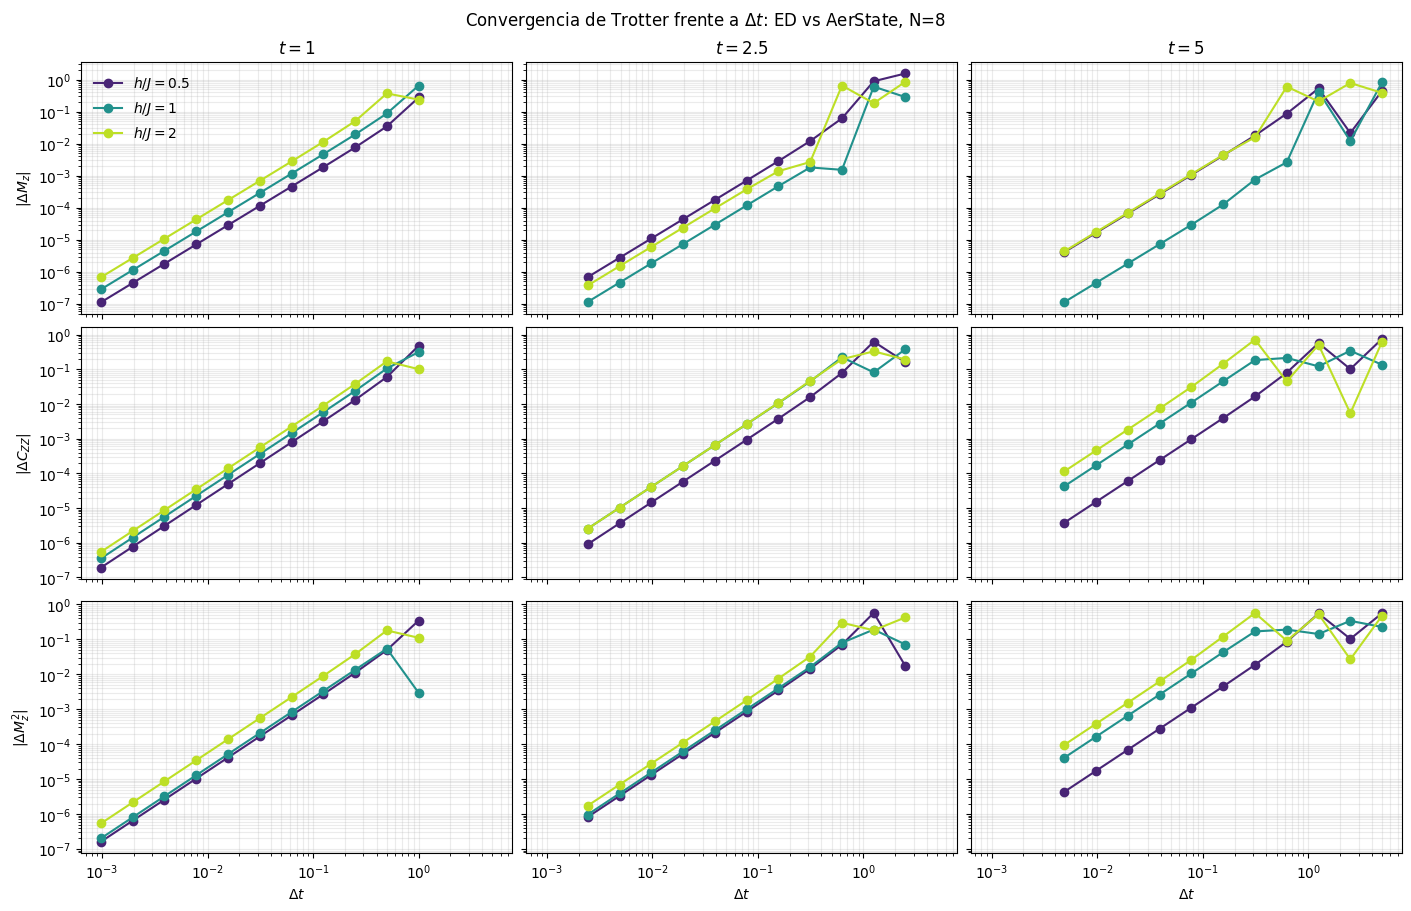

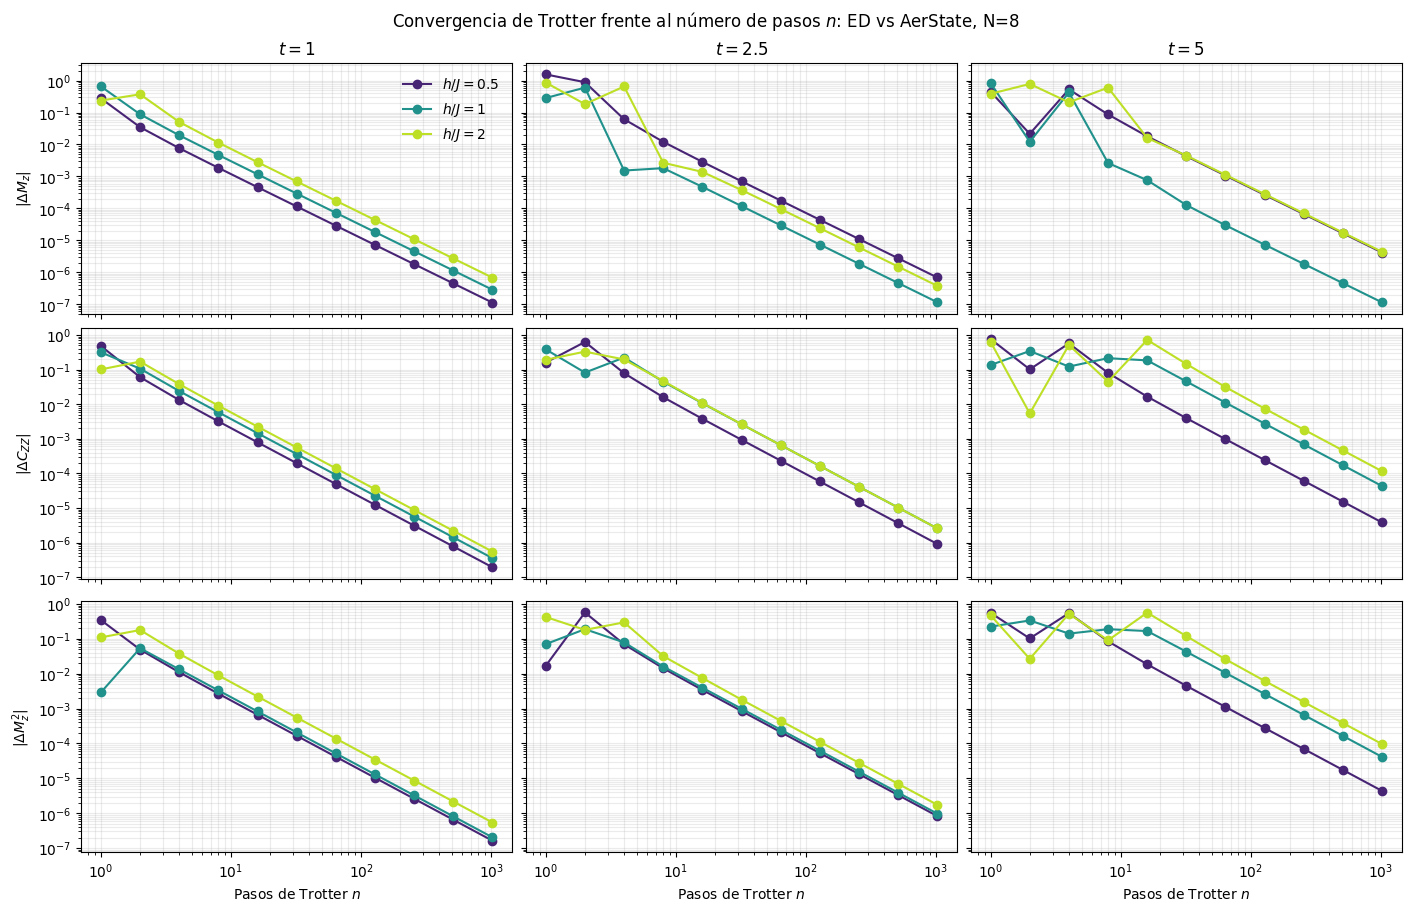

,h_over_J,time,trotter_steps,dt,sim_mz,exact_mz,abs_error_mz,sim_mz2,exact_mz2,abs_error_mz2,sim_czz,exact_czz,abs_error_czz
0,0.5,1.0,1,1.0000,0.540302,0.81759,0.277288,0.380436,0.725233,0.344797,0.291927,0.771564,0.479637
1,0.5,1.0,2,0.5000,0.782786,0.81759,0.034804,0.675886,0.725233,0.049347,0.711262,0.771564,0.060302
2,0.5,1.0,4,0.2500,0.809933,0.81759,0.007657,0.714223,0.725233,0.011010,0.758419,0.771564,0.013145
3,0.5,1.0,8,0.1250,0.815733,0.81759,0.001858,0.722554,0.725233,0.002679,0.768382,0.771564,0.003181
4,0.5,1.0,16,0.0625,0.817129,0.81759,0.000461,0.724568,0.725233,0.000665,0.770775,0.771564,0.000789


In [100]:
convergence_csv_path = Path.cwd() / "trotter_convergence_results.csv"

if convergence_csv_path.exists():
    convergence_df = pd.read_csv(convergence_csv_path)
    print(f"Usando resultados guardados: {convergence_csv_path}")
else:
    convergence_run_dir = latest_run_directory(CONVERGENCE_RUN_LABEL)
    convergence_execution_records = recover_execution_records(
        convergence_run_dir
    )

    rows = []
    for record in convergence_execution_records:
        sim_mz, sim_mz2, sim_czz = z_observables_from_probability_result(
            record["backend_result"],
            convergence_n,
        )
        exact_mz, exact_mz2, exact_czz = exact_reference_observables(
            h=record["ratio"] * convergence_J,
            J=convergence_J,
            t=record["time"],
            n=convergence_n,
        )
        rows.append(
            {
                "h_over_J": record["ratio"],
                "time": record["time"],
                "trotter_steps": record["steps"],
                "dt": record["dt"],
                "sim_mz": sim_mz,
                "exact_mz": exact_mz,
                "abs_error_mz": abs(sim_mz - exact_mz),
                "sim_mz2": sim_mz2,
                "exact_mz2": exact_mz2,
                "abs_error_mz2": abs(sim_mz2 - exact_mz2),
                "sim_czz": sim_czz,
                "exact_czz": exact_czz,
                "abs_error_czz": abs(sim_czz - exact_czz),
            }
        )

    convergence_df = (
        pd.DataFrame(rows)
        .sort_values(["time", "h_over_J", "trotter_steps"])
        .reset_index(drop=True)
    )
    convergence_df.to_csv(convergence_csv_path, index=False)


def plot_trotter_errors(
    convergence_df,
    x_column,
    x_label,
    title_suffix,
):
    figure, axes = plt.subplots(
        3,
        len(convergence_times),
        figsize=(14, 9),
        sharex=True,
        sharey="row",
        constrained_layout=True,
    )
    error_specs = [
        ("abs_error_mz", r"$|\Delta M_z|$"),
        ("abs_error_czz", r"$|\Delta C_{ZZ}|$"),
        ("abs_error_mz2", r"$|\Delta M_z^2|$"),
    ]
    colors = plt.cm.viridis(
        np.linspace(0.1, 0.9, len(convergence_hj_ratios))
    )

    for column, time in enumerate(convergence_times):
        time_data = convergence_df[
            np.isclose(convergence_df["time"], time)
        ]
        for row, (error_column, ylabel) in enumerate(error_specs):
            axis = axes[row, column]
            for color, ratio in zip(colors, convergence_hj_ratios):
                ratio_data = time_data[
                    np.isclose(time_data["h_over_J"], ratio)
                ].sort_values(x_column)
                axis.loglog(
                    ratio_data[x_column],
                    np.maximum(
                        ratio_data[error_column],
                        np.finfo(float).tiny,
                    ),
                    color=color,
                    marker="o",
                    linewidth=1.5,
                    label=fr"$h/J={ratio:.3g}$",
                )
            if row == 0:
                axis.set_title(fr"$t={time:g}$")
            if column == 0:
                axis.set_ylabel(ylabel)
            if row == len(error_specs) - 1:
                axis.set_xlabel(x_label)
            axis.grid(True, which="both", alpha=0.25)

    axes[0, 0].legend(frameon=False)
    figure.suptitle(
        f"Convergencia de Trotter {title_suffix}: "
        f"ED vs AerState, N={convergence_n}"
    )
    return figure, axes


convergence_dt_figure, convergence_dt_axes = plot_trotter_errors(
    convergence_df,
    x_column="dt",
    x_label=r"$\Delta t$",
    title_suffix=r"frente a $\Delta t$",
)
plt.show()

convergence_steps_figure, convergence_steps_axes = plot_trotter_errors(
    convergence_df,
    x_column="trotter_steps",
    x_label=r"Pasos de Trotter $n$",
    title_suffix=r"frente al número de pasos $n$",
)
plt.show()

convergence_df.head()


In [ ]:
N_shots = 10_000

def submit_or_resume_statevector_scan(
    circuits,
    scan_records,
    project,
    run_label,
    optimisation_level=0,
    force_new=False,
):
    run_directory = (
        None
        if force_new
        else latest_run_directory(run_label, required=False)
    )
    if run_directory is not None:
        execute_path = run_directory / "execute-job"
        compile_path = run_directory / "compile-job"
        if execute_path.exists():
            execute_job = qnx.filesystem.load(path=execute_path)
            qnx.jobs.wait_for(execute_job)
            print(f"Ejecución   recuperada: {run_directory}")
            return run_directory
        if compile_path.exists():
            records = load_scan_records(run_directory)
            backend_config = qnx.QuantinuumConfig(
                device_name="H2-1LE",
                n_qubits=max(int(record["n"]) for record in records),
            )
            compile_job = qnx.filesystem.load(path=compile_path)
            qnx.jobs.wait_for(compile_job)
            compiled_circuits = [
                result.get_output()
                for result in qnx.jobs.results(compile_job)
            ]
            execute_job = qnx.start_execute_job(
                programs=compiled_circuits,
                backend_config=backend_config,
                n_shots=[N_shots] * len(compiled_circuits),
                name=f"{run_label}-execute-{run_directory.name}",
                project=project,
            )
            save_job_reference(execute_job, execute_path)
            qnx.jobs.wait_for(execute_job)
            print(f"Ejecución AerState reanudada: {run_directory}")
            return run_directory

    if len(circuits) != len(scan_records):
        raise ValueError(
            f"Se recibieron {len(circuits)} circuitos y "
            f"{len(scan_records)} registros."
        )
    if not circuits:
        raise ValueError("No hay circuitos para ejecutar.")

    run_suffix = datetime.datetime.now().strftime(
        "%Y_%m_%d-%H_%M_%S_%f"
    )
    run_directory = prepare_run_directory(
        run_label,
        run_suffix,
        scan_records,
    )
    backend_config = qnx.QuantinuumConfig(
        device_name="H2-1LE",
        n_qubits=scan_records[0]["n"],
    )

    circuit_refs = [
        qnx.circuits.upload(
            circuit=circuit,
            name=record["name"],
        )
        for circuit, record in tqdm(
            zip(circuits, scan_records, strict=True),
            total=len(circuits),
            desc="Subiendo circuitos AerState",
            unit="circuito",
        )
    ]

    compile_job = qnx.start_compile_job(
        programs=circuit_refs,
        backend_config=backend_config,
        optimisation_level=optimisation_level,
        name=f"{run_label}-compile-{run_suffix}",
        project=project,
    )
    save_job_reference(compile_job, run_directory / "compile-job")
    qnx.jobs.wait_for(compile_job)
    compiled_circuits = [
        result.get_output()
        for result in qnx.jobs.results(compile_job)
    ]

    execute_job = qnx.start_execute_job(
        programs=compiled_circuits,
        backend_config=backend_config,
        n_shots=[N_shots] * len(compiled_circuits),
        name=f"{run_label}-execute-{run_suffix}",
        project=project,
    )
    save_job_reference(execute_job, run_directory / "execute-job")
    qnx.jobs.wait_for(execute_job)
    print(f"Ejecución AerState guardada: {run_directory}")
    return run_directory


trotter_step_values = np.array(
    [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
)
convergence_hj_ratios = np.array([0.5, 1.0, 2.0])
convergence_times = np.array([1.0, 2.5, 5.0])
convergence_n = 8
convergence_J = 1.0
CONVERGENCE_RUN_LABEL = "trotter-convergence-n8-v2-h2-1le"
FORCE_NEW_CONVERGENCE_RUN = False

convergence_circuits = []
convergence_records = []
saved_convergence_run = (
    None
    if FORCE_NEW_CONVERGENCE_RUN
    else latest_run_directory(CONVERGENCE_RUN_LABEL, required=False)
)
has_saved_convergence_job = (
    saved_convergence_run is not None
    and (
        (saved_convergence_run / "compile-job").exists()
        or (saved_convergence_run / "execute-job").exists()
    )
)

if not has_saved_convergence_job:
    for trotter_steps in tqdm(
        trotter_step_values,
        desc="Generando circuitos de convergencia",
        unit="steps",
    ):
        step_circuits, step_records, _ = generate_tfim_trotter_scan(
            hj_ratios=convergence_hj_ratios,
            times=convergence_times,
            J=convergence_J,
            steps=int(trotter_steps),
            n=convergence_n,
            measure=False,
            name_prefix=f"tfim-convergence-s{int(trotter_steps)}",
        )
        convergence_circuits.extend(step_circuits)
        convergence_records.extend(step_records)

convergence_run_dir = submit_or_resume_statevector_scan(
    circuits=convergence_circuits,
    scan_records=convergence_records,
    project=project,
    run_label=CONVERGENCE_RUN_LABEL,
    optimisation_level=0,
    force_new=FORCE_NEW_CONVERGENCE_RUN,
)


/Users/anotherdev/workspace/quanthathon/project/qnexus_runs/trotter-convergence-n8-v2-h2-1le/2026_07_23-10_24_37_764087/execute-job
Ejecución   recuperada: /Users/anotherdev/workspace/quanthathon/project/qnexus_runs/trotter-convergence-n8-v2-h2-1le/2026_07_23-10_24_37_764087


In [181]:
convergence_csv_path = Path.cwd() / "trotter_convergence_results-h2-1le.csv"

if convergence_csv_path.exists():
    convergence_df = pd.read_csv(convergence_csv_path)
    print(f"Usando resultados guardados: {convergence_csv_path}")
else:
    convergence_run_dir = latest_run_directory(CONVERGENCE_RUN_LABEL)
    convergence_execution_records = recover_execution_records(
        convergence_run_dir
    )

    rows = []
    for record in convergence_execution_records:
        sim_mz, sim_mz2, sim_czz = z_observables_from_empirical_result(
            record["backend_result"],
            convergence_n,
        )
        exact_mz, exact_mz2, exact_czz = exact_reference_observables(
            h=record["ratio"] * convergence_J,
            J=convergence_J,
            t=record["time"],
            n=convergence_n,
        )
        rows.append(
            {
                "h_over_J": record["ratio"],
                "time": record["time"],
                "trotter_steps": record["steps"],
                "dt": record["dt"],
                "sim_mz": sim_mz,
                "exact_mz": exact_mz,
                "abs_error_mz": abs(sim_mz - exact_mz),
                "sim_mz2": sim_mz2,
                "exact_mz2": exact_mz2,
                "abs_error_mz2": abs(sim_mz2 - exact_mz2),
                "sim_czz": sim_czz,
                "exact_czz": exact_czz,
                "abs_error_czz": abs(sim_czz - exact_czz),
            }
        )

    convergence_df = (
        pd.DataFrame(rows)
        .sort_values(["time", "h_over_J", "trotter_steps"])
        .reset_index(drop=True)
    )
    convergence_df.to_csv(convergence_csv_path, index=False)


def plot_trotter_errors(
    convergence_df,
    x_column,
    x_label,
    title_suffix,
):
    figure, axes = plt.subplots(
        3,
        len(convergence_times),
        figsize=(14, 9),
        sharex=True,
        sharey="row",
        constrained_layout=True,
    )
    error_specs = [
        ("abs_error_mz", r"$|\Delta M_z|$"),
        ("abs_error_czz", r"$|\Delta C_{ZZ}|$"),
        ("abs_error_mz2", r"$|\Delta M_z^2|$"),
    ]
    colors = plt.cm.viridis(
        np.linspace(0.1, 0.9, len(convergence_hj_ratios))
    )

    for column, time in enumerate(convergence_times):
        time_data = convergence_df[
            np.isclose(convergence_df["time"], time)
        ]
        for row, (error_column, ylabel) in enumerate(error_specs):
            axis = axes[row, column]
            for color, ratio in zip(colors, convergence_hj_ratios):
                ratio_data = time_data[
                    np.isclose(time_data["h_over_J"], ratio)
                ].sort_values(x_column)
                axis.loglog(
                    ratio_data[x_column],
                    np.maximum(
                        ratio_data[error_column],
                        np.finfo(float).tiny,
                    ),
                    color=color,
                    marker="o",
                    linewidth=1.5,
                    label=fr"$h/J={ratio:.3g}$",
                )
            if row == 0:
                axis.set_title(fr"$t={time:g}$")
            if column == 0:
                axis.set_ylabel(ylabel)
            if row == len(error_specs) - 1:
                axis.set_xlabel(x_label)
            axis.grid(True, which="both", alpha=0.25)

    axes[0, 0].legend(frameon=False)
    figure.suptitle(
        f"Convergencia de Trotter {title_suffix}: "
        f"ED vs AerState, N={convergence_n}"
    )
    return figure, axes


convergence_dt_figure, convergence_dt_axes = plot_trotter_errors(
    convergence_df,
    x_column="dt",
    x_label=r"$\Delta t$",
    title_suffix=r"frente a $\Delta t$",
)
plt.show()

convergence_steps_figure, convergence_steps_axes = plot_trotter_errors(
    convergence_df,
    x_column="trotter_steps",
    x_label=r"Pasos de Trotter $n$",
    title_suffix=r"frente al número de pasos $n$",
)
plt.show()

convergence_df.head()


ResourceFetchFailed: Failed to fetch resource with status code: None
Message: Job status: CANCELLED

Usando errores guardados: /Users/anotherdev/workspace/quanthathon/project/h2_absolute_errors.csv


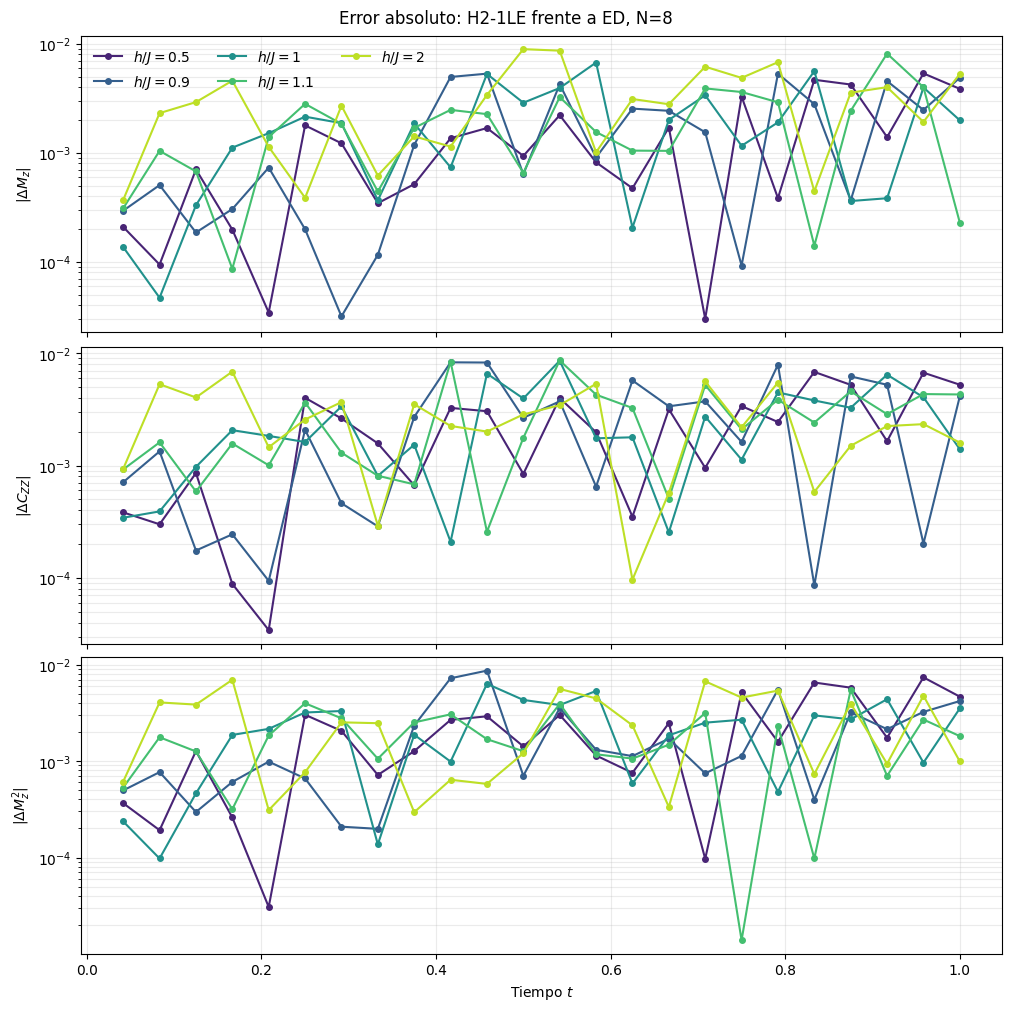

In [174]:
dynamics_error_csv_path = Path.cwd() / "h2_absolute_errors.csv"

if dynamics_error_csv_path.exists():
    dynamics_error_df = pd.read_csv(dynamics_error_csv_path)
    print(f"Usando errores guardados: {dynamics_error_csv_path}")
else:
    dynamics_error_df = h2_absolute_error_dataframe(
        execution_records=execution_records,
        hj_ratios=hj_ratios,
        times=times_simulator,
        J=J,
        n=n,
    )
    dynamics_error_df.to_csv(dynamics_error_csv_path, index=False)

dynamics_error_figure, dynamics_error_axes = graph_h2_absolute_errors(
    dynamics_error_df,
    n=n,
)
plt.show()

## 10) Coste físico de la aproximación de Trotter

Esta sección cuantifica el compromiso entre precisión y coste del circuito. Para
aislar el efecto del número de pasos se fija el punto representativo
$h/J=1$, $t=5$ y $N=8$, y solo se modifica `trotter_steps`.

Los circuitos se compilan para H2-1LE antes de medir profundidad y número de
puertas. Las medidas y barreras no se cuentan como puertas cuánticas. El error
absoluto procede del barrido AerState frente a ED en el mismo punto, separado
para $M_z$, $M_z^2$ y $C_{ZZ}$.

La primera celda envía o recupera únicamente el trabajo de compilación. La
referencia queda guardada antes de consultar los resultados, por lo que el
análisis puede reanudarse sin volver a enviar los circuitos.


In [123]:
COST_BACKEND_NAME = "H2-1LE"
COST_RUN_LABEL = "h2-trotter-cost-n8-r1-t5-v1"
COST_HJ_RATIO = 1.0
COST_TIME = 5.0
COST_N = convergence_n
COST_J = convergence_J
COST_STEP_VALUES = np.asarray(trotter_step_values, dtype=int)

cost_backend_config = qnx.QuantinuumConfig(
    device_name=COST_BACKEND_NAME,
)
saved_cost_run = latest_run_directory(
    COST_RUN_LABEL,
    required=False,
)
has_saved_cost_compile = (
    saved_cost_run is not None
    and (saved_cost_run / "compile-job").exists()
)

if has_saved_cost_compile:
    cost_run_dir = saved_cost_run
    print(f"Reutilizando compilación H2-1LE: {cost_run_dir}")
else:
    cost_suffix = datetime.datetime.now().strftime(
        "%Y_%m_%d-%H_%M_%S_%f"
    )
    cost_circuits = []
    cost_records = []

    for index, trotter_steps in enumerate(COST_STEP_VALUES):
        circuit = build_trotter_circuit(
            h=COST_HJ_RATIO * COST_J,
            J=COST_J,
            t=COST_TIME,
            steps=int(trotter_steps),
            n_qbits=COST_N,
        )
        circuit.measure_all()
        name = (
            f"tfim-cost-s{int(trotter_steps)}-"
            f"{cost_suffix}-{index}"
        )
        cost_circuits.append(circuit)
        cost_records.append(
            {
                "index": index,
                "trotter_steps": int(trotter_steps),
                "h_over_J": COST_HJ_RATIO,
                "time": COST_TIME,
                "J": COST_J,
                "n": COST_N,
                "name": name,
            }
        )

    cost_run_dir = prepare_run_directory(
        COST_RUN_LABEL,
        cost_suffix,
        cost_records,
    )
    cost_circuit_refs = [
        qnx.circuits.upload(
            circuit=circuit,
            name=record["name"],
        )
        for circuit, record in tqdm(
            zip(cost_circuits, cost_records, strict=True),
            total=len(cost_circuits),
            desc="Subiendo circuitos de coste",
            unit="circuito",
        )
    ]
    cost_compile_job = qnx.start_compile_job(
        programs=cost_circuit_refs,
        backend_config=cost_backend_config,
        optimisation_level=2,
        name=f"{COST_RUN_LABEL}-compile-{cost_suffix}",
        project=project,
    )
    save_job_reference(
        cost_compile_job,
        cost_run_dir / "compile-job",
    )
    print(f"Compilación H2-1LE enviada: {cost_run_dir}")


Subiendo circuitos de coste:   0%|          | 0/11 [00:00<?, ?circuito/s]

Compilación H2-1LE enviada: /Users/anotherdev/workspace/quanthathon/project/qnexus_runs/h2-trotter-cost-n8-r1-t5-v1/2026_07_23-08_32_09_481729


In [16]:
from collections import Counter

from pytket.circuit import OpType


IGNORED_COST_OPERATIONS = {
    OpType.Barrier,
    OpType.Collapse,
    OpType.Measure,
    OpType.Reset,
}


def compiled_circuit_metrics(circuit):
    wire_depth = {qubit: 0 for qubit in circuit.qubits}
    one_qubit_gates = 0
    two_qubit_gates = 0
    multi_qubit_gates = 0
    two_qubit_gate_types = Counter()

    for command in circuit.get_commands():
        if command.op.type in IGNORED_COST_OPERATIONS:
            continue

        qubits = list(command.qubits)
        if not qubits:
            continue

        layer = 1 + max(wire_depth[qubit] for qubit in qubits)
        for qubit in qubits:
            wire_depth[qubit] = layer

        arity = len(qubits)
        if arity == 1:
            one_qubit_gates += 1
        elif arity == 2:
            two_qubit_gates += 1
            operation_name = getattr(
                command.op.type,
                "name",
                str(command.op.type),
            )
            two_qubit_gate_types[operation_name] += 1
        else:
            multi_qubit_gates += 1

    return {
        "compiled_depth": max(wire_depth.values(), default=0),
        "one_qubit_gates": one_qubit_gates,
        "two_qubit_gates": two_qubit_gates,
        "multi_qubit_gates": multi_qubit_gates,
        "two_qubit_gate_types": ", ".join(
            f"{gate}={count}"
            for gate, count in sorted(two_qubit_gate_types.items())
        ),
    }


cost_compile_job = qnx.filesystem.load(
    path=cost_run_dir / "compile-job"
)
cost_job_status = qnx.jobs.status(cost_compile_job)
cost_status_value = getattr(
    cost_job_status.status,
    "value",
    str(cost_job_status.status),
)
if cost_status_value != "COMPLETED":
    raise RuntimeError(
        f"La compilación está en estado {cost_status_value}. "
        "Vuelve a ejecutar esta celda cuando termine."
    )

cost_records = load_scan_records(cost_run_dir)
cost_result_refs = qnx.jobs.results(cost_compile_job)
if len(cost_result_refs) != len(cost_records):
    raise RuntimeError(
        f"Se encontraron {len(cost_result_refs)} circuitos compilados "
        f"para {len(cost_records)} registros."
    )

compiled_cache_dir = cost_run_dir / "compiled_cache"
compiled_cache_dir.mkdir(exist_ok=True)
compiled_cost_circuits = []

for index, result_ref in enumerate(
    tqdm(
        cost_result_refs,
        desc="Recuperando circuitos compilados",
        unit="circuito",
    )
):
    cache_path = compiled_cache_dir / f"{index:04d}.json"
    if cache_path.exists():
        compiled_circuit = Circuit.from_dict(
            json.loads(cache_path.read_text(encoding="utf-8"))
        )
    else:
        compiled_circuit_ref = result_ref.get_output()
        compiled_circuit = compiled_circuit_ref.download_circuit()
        temporary_path = cache_path.with_suffix(".tmp")
        temporary_path.write_text(
            json.dumps(compiled_circuit.to_dict()),
            encoding="utf-8",
        )
        temporary_path.replace(cache_path)
    compiled_cost_circuits.append(compiled_circuit)

cost_rows = []
for record, compiled_circuit in zip(
    cost_records,
    compiled_cost_circuits,
    strict=True,
):
    trotter_steps = int(record["trotter_steps"])
    error_row = convergence_df[
        np.isclose(convergence_df["h_over_J"], COST_HJ_RATIO)
        & np.isclose(convergence_df["time"], COST_TIME)
        & (convergence_df["trotter_steps"] == trotter_steps)
    ]
    if len(error_row) != 1:
        raise RuntimeError(
            f"No se encontró un error único para {trotter_steps} pasos."
        )

    errors = error_row.iloc[0]
    cost_rows.append(
        {
            "trotter_steps": trotter_steps,
            **compiled_circuit_metrics(compiled_circuit),
            "abs_error_mz": float(errors["abs_error_mz"]),
            "abs_error_mz2": float(errors["abs_error_mz2"]),
            "abs_error_czz": float(errors["abs_error_czz"]),
        }
    )

trotter_cost_df = (
    pd.DataFrame(cost_rows)
    .sort_values("trotter_steps")
    .reset_index(drop=True)
)
trotter_cost_csv_path = (
    Path.cwd() / "trotter_compiled_cost_vs_error.csv"
)
trotter_cost_df.to_csv(trotter_cost_csv_path, index=False)
trotter_cost_df


NameError: name 'cost_run_dir' is not defined

## 11) Estado fundamental del TFIM con VQE

Para cada valor de $h/J$ buscamos parámetros $\theta$ que minimicen

$$
E(\theta)=
\langle\psi(\theta)|H_{\mathrm{TFIM}}|\psi(\theta)\rangle,
\qquad
|\psi(\theta)\rangle=U(\theta)|\psi(0)\rangle.
$$

El ansatz simbólico $U(\theta)$ y el Hamiltoniano se definen manualmente en la
siguiente celda. Después, COBYLA evalúa la energía ejecutando los circuitos de
medida en `H2-1LE` con 500 shots. Los mejores parámetros de un valor de $h/J$
se reutilizan como punto inicial del siguiente.

Al terminar cada optimización, el circuito óptimo se ejecuta con 10 000 shots
para calcular la energía, $M_z$, $M_z^2$, $M_x$ y $C_{ZZ}$. Los resultados se
guardan progresivamente y se comparan con diagonalización exacta.


> **Referencia de implementación**
>
> Quantinuum Nexus, [VQE workflow using Quantinuum Nexus](https://docs.quantinuum.com/nexus/trainings/notebooks/knowledge_articles/vqe_example.html).
>
> El flujo de sustitución de parámetros, construcción de circuitos de medida,
> compilación, ejecución en `H2-1LE` y optimización con COBYLA está adaptado de
> este ejemplo oficial.


In [17]:
from pytket import Circuit
from sympy import symbols
from pytket.utils.operators import QubitPauliOperator,  Qubit
from pytket.pauli import Pauli, QubitPauliString



def build_vqe_ansatz(n: int) -> Circuit:
    """Devuelve tu circuito simbólico U(theta)|psi(0)>."""
    # Define aquí el ansatz y sus símbolos.
    # Debe devolverse un pytket.Circuit con al menos un símbolo libre.

    gamma, beta = symbols("gamma beta")
    c = Circuit(n)
    for q in range(n-1):
        c.ZZPhase(gamma, q, q+1)
    for q in range(n):
        c.Rx(beta, q)
    return c






def build_vqe_hamiltonian(
    h: float,
    J: float,
    n: int,
) -> QubitPauliOperator:
    """Devuelve tu Hamiltoniano TFIM para los valores indicados."""
    # Define aquí el QubitPauliOperator que se minimizará.
    terms = {}

    for i in range(n - 1):
        zz_string = QubitPauliString(
            {
                Qubit(i): Pauli.Z,
                Qubit(i + 1): Pauli.Z,
            }
        )
        terms[zz_string] = -float(J)

    for i in range(n):
        x_string = QubitPauliString(
            {
                Qubit(i): Pauli.X,
            }
        )
        terms[x_string] = -float(h)

    return QubitPauliOperator(terms)


Local h/J=2, plus: E=-16.882757616, success=True
Local h/J=1, plus: E=-9.761347498, success=True
Local h/J=0.5, plus: E=-7.050152615, success=True
Local h/J=0.5, ghz: E=-7.623629635, success=True
Local h/J=1, ghz: E=-9.344197270, success=True
Local h/J=2, ghz: E=-14.264817291, success=True
Elegido h/J=0.5: ghz, E=-7.623629635, ED=-7.640592554
Elegido h/J=1: plus, E=-9.761347498, ED=-9.837951447
Elegido h/J=2: plus, E=-16.882757616, ED=-16.885141493
Resultados guardados en /Users/anotherdev/workspace/quanthathon/project/tfim-vqe-hva-p4-n8-v2-results.csv


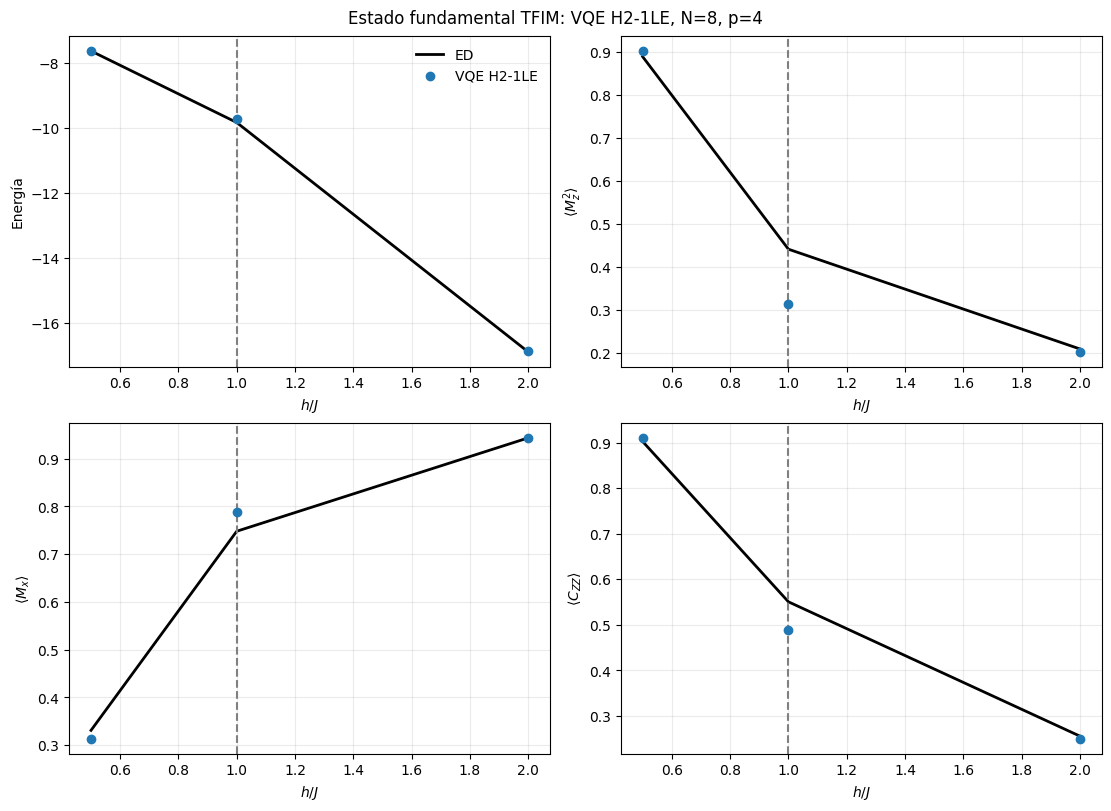

,h_over_J,reference,depth,parameters,optimizer_energy,optimizer_success,optimizer_evaluations,vqe_energy,vqe_mz,vqe_mz2,...,se_mz,se_mz2,se_mx,se_czz,ed_energy,ed_mz,ed_mz2,ed_mx,ed_czz,abs_error_energy
0,0.5,ghz,4,"[0.8658600911810295, -0.8752168477977444, 0.07...",-7.623630,True,5436,-7.6326,0.012075,0.901969,...,0.009497,0.002029,0.003453,0.001963,-7.640593,-3.580469e-14,0.887993,0.331024,0.902357,0.007993
1,1.0,plus,4,"[-0.837344238803222, 1.0, -0.9092883137261512,...",-9.761347,True,2367,-9.7212,0.007675,0.313431,...,0.005598,0.003291,0.002963,0.003450,-9.837951,1.637579e-15,0.440391,0.747924,0.550652,0.116751
2,2.0,plus,4,"[-0.8838680378461975, 1.0, -0.9582590093658597...",-16.882758,True,3753,-16.8574,-0.005475,0.201669,...,0.004491,0.002434,0.001632,0.003751,-16.885141,-2.220446e-16,0.208444,0.943363,0.255904,0.027741


In [198]:
from datetime import datetime
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import qnexus as qnx
from pytket import Circuit
from pytket.circuit import Qubit
from pytket.pauli import Pauli, QubitPauliString
from pytket.utils.operators import QubitPauliOperator
from scipy.optimize import minimize
from scipy.stats import qmc
from sympy import Symbol


# La optimización es local y exacta; Nexus se usa una sola vez al final.
VQE_N = 8
VQE_J = 1.0
VQE_HJ_RATIOS = np.array([0.5, 1.0, 2.0])
# VQE_HJ_RATIOS = np.linspace(0.1, 2.5, 50)
VQE_DEPTH = 4
VQE_STARTS = 8
VQE_MAXITER = 300
VQE_FINAL_SHOTS = 10_000
VQE_RANDOM_SEED = 7
VQE_RUN_LABEL = f"tfim-vqe-hva-p{VQE_DEPTH}-n{VQE_N}-v2"
VQE_BACKEND = qnx.QuantinuumConfig(device_name="H2-1LE")


def _build_tfim_hamiltonian(h: float) -> QubitPauliOperator:
    terms = {}
    for site in range(VQE_N - 1):
        terms[
            QubitPauliString(
                {
                    Qubit(site): Pauli.Z,
                    Qubit(site + 1): Pauli.Z,
                }
            )
        ] = -VQE_J
    for site in range(VQE_N):
        terms[QubitPauliString({Qubit(site): Pauli.X})] = -float(h)
    return QubitPauliOperator(terms)


def _build_hva_ansatz(reference: str):
    if reference not in {"plus", "ghz"}:
        raise ValueError(f"Referencia desconocida: {reference}")

    circuit = Circuit(
        VQE_N,
        name=f"tfim-{reference}-p{VQE_DEPTH}",
    )
    symbols = tuple(
        symbol
        for layer in range(VQE_DEPTH)
        for symbol in (
            Symbol(f"{reference}_gamma_{layer}"),
            Symbol(f"{reference}_beta_{layer}"),
        )
    )

    if reference == "plus":
        for qubit in range(VQE_N):
            circuit.H(qubit)
    else:
        circuit.H(0)
        for qubit in range(VQE_N - 1):
            circuit.CX(qubit, qubit + 1)

    for layer in range(VQE_DEPTH):
        gamma, beta = symbols[2 * layer : 2 * layer + 2]

        # Evita que la primera capa sea sólo una fase global.
        if reference == "ghz":
            for qubit in range(VQE_N):
                circuit.Rx(beta, qubit)

        for qubit in range(VQE_N - 1):
            circuit.ZZPhase(gamma, qubit, qubit + 1)

        if reference == "plus":
            for qubit in range(VQE_N):
                circuit.Rx(beta, qubit)

    return circuit, symbols


def _bind_circuit(symbolic_circuit, symbols, parameters):
    parameters = np.asarray(parameters, dtype=float)
    if parameters.shape != (len(symbols),):
        raise ValueError("Número incorrecto de parámetros VQE.")
    if not np.all(np.isfinite(parameters)):
        raise ValueError("Los parámetros VQE deben ser finitos.")

    circuit = symbolic_circuit.copy()
    circuit.symbol_substitution(
        dict(zip(symbols, parameters, strict=True))
    )
    if circuit.free_symbols():
        raise RuntimeError("Quedaron símbolos libres en el circuito.")
    return circuit


def _statevector_energy(
    symbolic_circuit,
    symbols,
    parameters,
    hamiltonian,
):
    state = _bind_circuit(
        symbolic_circuit,
        symbols,
        parameters,
    ).get_statevector()
    return float(
        np.real_if_close(hamiltonian.state_expectation(state))
    )


def _optimise_reference(
    ratio: float,
    reference: str,
    warm_start=None,
):
    symbolic_circuit, symbols = _build_hva_ansatz(reference)
    hamiltonian = _build_tfim_hamiltonian(ratio * VQE_J)
    parameter_count = len(symbols)

    seed = (
        VQE_RANDOM_SEED
        + int(round(1000 * ratio))
        + (100_000 if reference == "ghz" else 0)
    )
    sobol_power = int(np.ceil(np.log2(VQE_STARTS)))
    sobol_starts = qmc.Sobol(
        d=parameter_count,
        scramble=True,
        seed=seed,
    ).random_base2(sobol_power)[:VQE_STARTS]

    starts = [np.zeros(parameter_count)]
    if warm_start is not None:
        starts.append(np.asarray(warm_start, dtype=float))
    starts.extend(2.0 * sobol_starts - 1.0)

    def objective(parameters):
        return _statevector_energy(
            symbolic_circuit,
            symbols,
            parameters,
            hamiltonian,
        )

    runs = []
    for initial_parameters in starts:
        runs.append(
            minimize(
                objective,
                initial_parameters,
                method="L-BFGS-B",
                bounds=[(-1.0, 1.0)] * parameter_count,
                options={
                    "maxiter": VQE_MAXITER,
                    "ftol": 1e-11,
                    "gtol": 1e-7,
                    "maxls": 50,
                },
            )
        )

    finite_runs = [run for run in runs if np.isfinite(run.fun)]
    if not finite_runs:
        raise RuntimeError(
            f"No hubo solución finita para {ratio=}, {reference=}."
        )

    best = min(finite_runs, key=lambda run: float(run.fun))
    parameters = np.asarray(best.x, dtype=float)
    energy = objective(parameters)
    return {
        "reference": reference,
        "symbolic_circuit": symbolic_circuit,
        "symbols": symbols,
        "parameters": parameters,
        "local_energy": energy,
        "optimizer_success": bool(best.success),
        "optimizer_evaluations": int(sum(run.nfev for run in runs)),
        "optimizer_message": str(best.message),
    }


def _build_exact_hamiltonian_vqe(h: float) -> np.ndarray:
    """Misma diagonalización densa usada en exact.ipynb."""
    x = np.array([[0, 1], [1, 0]], dtype=complex)
    z = np.array([[1, 0], [0, -1]], dtype=complex)
    operator = lambda pauli, site: np.kron(
        np.eye(2**site),
        np.kron(pauli, np.eye(2 ** (VQE_N - site - 1))),
    )
    zero = np.zeros((2**VQE_N, 2**VQE_N), dtype=complex)
    hx = -h * sum(
        (operator(x, site) for site in range(VQE_N)), start=zero
    )
    hzz = -VQE_J * sum(
        (
            operator(z, site) @ operator(z, site + 1)
            for site in range(VQE_N - 1)
        ),
        start=zero,
    )
    return hx + hzz


def _exact_ground_state_values(ratio: float):
    eigenvalues, eigenvectors = np.linalg.eigh(
        _build_exact_hamiltonian_vqe(float(ratio * VQE_J))
    )
    ground_state = eigenvectors[:, 0]
    probabilities = np.abs(ground_state) ** 2
    basis = np.arange(2**VQE_N, dtype=np.uint64)
    positions = np.arange(VQE_N, dtype=np.uint64)
    bits = ((basis[:, None] >> positions) & 1).astype(int)
    z_values = 1 - 2 * bits
    mz_values = np.mean(z_values, axis=1)
    czz_values = np.mean(
        z_values[:, :-1] * z_values[:, 1:], axis=1
    )

    mx = 0.0
    for qubit in range(VQE_N):
        flipped = (basis ^ np.uint64(1 << qubit)).astype(int)
        mx += float(
            np.real(np.vdot(ground_state, ground_state[flipped]))
        )
    mx /= VQE_N

    return {
        "ed_energy": float(eigenvalues[0]),
        "ed_mz": float(probabilities @ mz_values),
        "ed_mz2": float(probabilities @ (mz_values**2)),
        "ed_mx": float(mx),
        "ed_czz": float(probabilities @ czz_values),
    }


def _sample_statistics(backend_result, basis: str):
    counts = (
        backend_result
        .get_empirical_distribution()
        .as_counter()
    )
    total_shots = int(sum(counts.values()))
    if total_shots < 2:
        raise ValueError("Se requieren al menos dos shots.")

    values = []
    weights = []
    for bitstring, count in counts.items():
        spins = 1 - 2 * np.asarray(tuple(bitstring), dtype=int)
        if basis == "z":
            mz = float(np.mean(spins))
            sample = np.array(
                [
                    mz,
                    mz**2,
                    np.mean(spins[:-1] * spins[1:]),
                ],
                dtype=float,
            )
        elif basis == "x":
            sample = np.array([np.mean(spins)], dtype=float)
        else:
            raise ValueError(f"Base desconocida: {basis}")
        values.append(sample)
        weights.append(int(count))

    values = np.asarray(values)
    weights = np.asarray(weights, dtype=float)
    means = np.average(values, axis=0, weights=weights)
    centered = values - means
    variances = np.sum(
        weights[:, None] * centered**2,
        axis=0,
    ) / (total_shots - 1)
    errors = np.sqrt(
        np.maximum(variances, 0.0) / total_shots
    )
    return means, errors


ratios = sorted(float(value) for value in VQE_HJ_RATIOS)
candidates = {}

# Cada referencia se continúa desde la fase donde es exacta.
for reference, ordered_ratios in (
    ("plus", list(reversed(ratios))),
    ("ghz", ratios),
):
    warm_start = None
    for ratio in ordered_ratios:
        candidate = _optimise_reference(
            ratio,
            reference,
            warm_start,
        )
        candidates[reference, ratio] = candidate
        warm_start = candidate["parameters"]
        print(
            f"Local h/J={ratio:g}, {reference}: "
            f"E={candidate['local_energy']:.9f}, "
            f"success={candidate['optimizer_success']}"
        )

chosen = {}
exact_values = {}
for ratio in ratios:
    chosen[ratio] = min(
        (
            candidates["plus", ratio],
            candidates["ghz", ratio],
        ),
        key=lambda item: item["local_energy"],
    )
    exact_values[ratio] = _exact_ground_state_values(ratio)

    if (
        chosen[ratio]["local_energy"]
        < exact_values[ratio]["ed_energy"] - 1e-8
    ):
        raise RuntimeError(
            f"Violación variacional para h/J={ratio:g}."
        )

    print(
        f"Elegido h/J={ratio:g}: "
        f"{chosen[ratio]['reference']}, "
        f"E={chosen[ratio]['local_energy']:.9f}, "
        f"ED={exact_values[ratio]['ed_energy']:.9f}"
    )


# Dos circuitos por ratio: Z obtiene Mz, Mz² y Czz; X obtiene Mx.
manifest = []
measurement_circuits = []
for ratio in ratios:
    candidate = chosen[ratio]
    state_prep = _bind_circuit(
        candidate["symbolic_circuit"],
        candidate["symbols"],
        candidate["parameters"],
    )

    z_circuit = state_prep.copy()
    z_circuit.measure_all()

    x_circuit = state_prep.copy()
    for qubit in range(VQE_N):
        x_circuit.H(qubit)
    x_circuit.measure_all()

    for basis, circuit in (("z", z_circuit), ("x", x_circuit)):
        manifest.append({"ratio": ratio, "basis": basis})
        measurement_circuits.append(circuit)


# Un solo upload batch, un compile y un execute en Nexus/H2-1LE.
project = qnx.projects.get_or_create(name="VQE-TFIM-H2-1LE")
qnx.context.set_active_project(project)
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
run_id = f"{VQE_RUN_LABEL}-{timestamp}"

circuit_refs = [
    qnx.circuits.upload(
        circuit=circuit,
        name=(
            f"{run_id}-r{record['ratio']:g}-"
            f"{record['basis']}"
        ),
        project=project,
    )
    for circuit, record in zip(
        measurement_circuits,
        manifest,
        strict=True,
    )
]

compiled_refs = qnx.compile(
    programs=circuit_refs,
    backend_config=VQE_BACKEND,
    optimisation_level=2,
    name=f"{run_id}-compile",
    project=project,
    timeout=None,
)

backend_results = qnx.execute(
    programs=compiled_refs,
    n_shots=[VQE_FINAL_SHOTS] * len(compiled_refs),
    backend_config=VQE_BACKEND,
    name=f"{run_id}-execute",
    project=project,
    timeout=None,
)

if len(backend_results) != len(manifest):
    raise RuntimeError("Nexus devolvió un número inesperado de resultados.")

result_map = {
    (record["ratio"], record["basis"]): result
    for record, result in zip(
        manifest,
        backend_results,
        strict=True,
    )
}


rows = []
for ratio in ratios:
    z_means, z_errors = _sample_statistics(
        result_map[ratio, "z"],
        "z",
    )
    x_means, x_errors = _sample_statistics(
        result_map[ratio, "x"],
        "x",
    )
    mz, mz2, czz = (float(value) for value in z_means)
    mz_error, mz2_error, czz_error = (
        float(value) for value in z_errors
    )
    mx = float(x_means[0])
    mx_error = float(x_errors[0])
    h = ratio * VQE_J
    energy = (
        -VQE_J * (VQE_N - 1) * czz
        -h * VQE_N * mx
    )
    energy_error = float(
        np.hypot(
            VQE_J * (VQE_N - 1) * czz_error,
            h * VQE_N * mx_error,
        )
    )

    candidate = chosen[ratio]
    row = {
        "h_over_J": ratio,
        "reference": candidate["reference"],
        "depth": VQE_DEPTH,
        "parameters": json.dumps(
            candidate["parameters"].tolist()
        ),
        "optimizer_energy": candidate["local_energy"],
        "optimizer_success": candidate["optimizer_success"],
        "optimizer_evaluations": (
            candidate["optimizer_evaluations"]
        ),
        "vqe_energy": float(energy),
        "vqe_mz": mz,
        "vqe_mz2": mz2,
        "vqe_mx": mx,
        "vqe_czz": czz,
        "se_energy": energy_error,
        "se_mz": mz_error,
        "se_mz2": mz2_error,
        "se_mx": mx_error,
        "se_czz": czz_error,
        **exact_values[ratio],
    }
    row["abs_error_energy"] = abs(
        row["vqe_energy"] - row["ed_energy"]
    )
    rows.append(row)

vqe_df = pd.DataFrame(rows).sort_values(
    "h_over_J"
).reset_index(drop=True)

vqe_results_path = (
    Path.cwd() / f"{VQE_RUN_LABEL}-results.csv"
)
vqe_df.to_csv(vqe_results_path, index=False)
print(f"Resultados guardados en {vqe_results_path}")


figure, axes = plt.subplots(
    2,
    2,
    figsize=(11, 8),
    constrained_layout=True,
)
plot_specs = [
    ("energy", axes[0, 0], "Energía"),
    ("mz2", axes[0, 1], r"$\langle M_z^2\rangle$"),
    ("mx", axes[1, 0], r"$\langle M_x\rangle$"),
    ("czz", axes[1, 1], r"$\langle C_{ZZ}\rangle$"),
]

for key, axis, ylabel in plot_specs:
    axis.plot(
        vqe_df["h_over_J"],
        vqe_df[f"ed_{key}"],
        color="black",
        linewidth=2,
        label="ED",
    )
    axis.scatter(
        vqe_df["h_over_J"],
        vqe_df[f"vqe_{key}"],
        color="tab:blue",
        label="VQE H2-1LE",
        zorder=3,
    )
    axis.axvline(1.0, color="gray", linestyle="--")
    axis.set_xlabel(r"$h/J$")
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.25)

axes[0, 0].legend(frameon=False)
figure.suptitle(
    f"Estado fundamental TFIM: VQE H2-1LE, N={VQE_N}, "
    f"p={VQE_DEPTH}"
)
plt.show()


error_figure, error_axis = plt.subplots(figsize=(7, 4))
error_axis.plot(
    vqe_df["h_over_J"],
    vqe_df["abs_error_energy"],
    marker="o",
    color="tab:red",
    linewidth=2,
)
error_axis.axvline(1.0, color="gray", linestyle="--")
error_axis.set_xlabel(r"$h/J$")
error_axis.set_ylabel(r"$|E_{VQE} - E_{exacta}|$")
error_axis.set_title("Error absoluto de la energía VQE")
error_axis.grid(alpha=0.25)
error_figure.tight_layout()
plt.show()

vqe_df
